# GRPO Ablations — Contrastive Pairing & Reward Components

Compiles results for two paper tables:
- **`tab:contrastive-ablation`**: Full reward at 0%, 5%, 10%, 15%, 20% contrastive pairing
- **`tab:reward-ablation`**: Cumulative reward component addition (structural → +context → +coherence → +ground)

All models are Qwen3.5-9B, SFT+GRPO with online R_ground.
Results are pulled from W&B `eval-all` project, differentiated by checkpoint path.

In [1]:
import wandb
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display, Latex

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.3f}".format)

# ── Configuration ──────────────────────────────────────────────────────────
WANDB_ENTITY = "uair"
WANDB_PROJECT = "eval-all"

# Map run timestamp (from checkpoint path) to ablation condition.
# These are the 2026-03-28 GRPO runs on Qwen3.5-9B.
ABLATION_RUNS = {
    # Contrastive ablation (full reward, varying contrastive ratio)
    "00-34-01": {"ablation": "contrastive_v1", "contrastive_ratio": 0.00, "reward_config": "full"},
    "00-34-23": {"ablation": "contrastive_v1", "contrastive_ratio": 0.05, "reward_config": "full"},
    "00-34-33": {"ablation": "contrastive_v1", "contrastive_ratio": 0.10, "reward_config": "full"},
    "00-34-51": {"ablation": "contrastive_v1", "contrastive_ratio": 0.15, "reward_config": "full"},
    "00-10-11": {"ablation": "contrastive_v1", "contrastive_ratio": 0.20, "reward_config": "full"},
    "15-44-21": {"ablation": "contrastive_v1", "contrastive_ratio": 0.50, "reward_config": "full"},
    "16-22-46": {"ablation": "contrastive_v1", "contrastive_ratio": 1, "reward_config": "full"},
    # ── v2: Per-completion dual scoring (varying contrastive_lambda) ──
    # Independent no-flow scoring + per-completion contrastive
    "11-28-41": {"ablation": "contrastive_v2", "contrastive_lambda": 0.5, "reward_config": "full_v2"},
    "11-39-49": {"ablation": "contrastive_v2", "contrastive_lambda": 1.0, "reward_config": "full_v2"},
    # Reward component ablation (10% contrastive throughout)
    "00-35-28": {"ablation": "reward", "contrastive_ratio": 0.10, "reward_config": "structural"},
    "00-36-05": {"ablation": "reward", "contrastive_ratio": 0.10, "reward_config": "+context"},
    "00-36-24": {"ablation": "reward", "contrastive_ratio": 0.10, "reward_config": "+coherence"},
    # 00-34-33 also serves as reward ablation row 4 (full, 10% contrastive)
}

# Display labels for tables
CONTRASTIVE_V1_LABELS = {
    0.00: "Full reward, no contrastive",
    0.05: "Full reward, 5\\% contrastive",
    0.10: "Full reward, 10\\% contrastive",
    0.15: "Full reward, 15\\% contrastive",
    0.20: "Full reward, 20\\% contrastive",
    0.50: "Full reward, 50\\% contrastive",
    1: "Full reward, 100\\% contrastive",
}

# v2 contrastive labels (per-completion dual scoring, independent no-flow)
CONTRASTIVE_V2_LABELS = {
    0.5: r"v2: $\lambda=0.5$",
    1.0: r"v2: $\lambda=1.0$",
}

# v2 run timestamps are from 2026-03-29_grpo_training (not 2026-03-28)
V2_TRAINING_DATE = "2026-03-29_grpo_training"


REWARD_LABELS = {
    "structural": r"Programmatic structural ($R_{\text{uncert}}$, $R_{\text{complete}}$, $R_{\text{consist}}$)",
    "+context":   r"+ Context identification ($R_{\text{context}}$)",
    "+coherence": r"+ Coherence ($R_{\text{cohere}}$)",
    "full":       r"+ Normative grounding ($R_{\text{ground}}$) = Full",
}

# SFT baseline checkpoint path fragment for comparison
SFT_BASELINE_CHECKPOINT = "sft_only"

api = wandb.Api()
print(f"Connected to W&B entity={WANDB_ENTITY}, project={WANDB_PROJECT}")


Connected to W&B entity=uair, project=eval-all


## 1. Fetch GRPO ablation runs from W&B

All ablation runs are tagged `grpo:grounded` and use Qwen3.5-9B.
We identify specific ablation conditions by matching the run timestamp
in the checkpoint path.

In [2]:
# Fetch all GRPO-grounded eval runs for Qwen3.5
all_runs = api.runs(
    f"{WANDB_ENTITY}/{WANDB_PROJECT}",
    filters={"tags": {"$all": ["grpo:grounded", "family:qwen3.5"]}},
)
print(f"Found {len(all_runs)} grpo:grounded qwen3.5 eval runs")

# Also fetch SFT-only baseline for comparison
sft_runs = api.runs(
    f"{WANDB_ENTITY}/{WANDB_PROJECT}",
    filters={"tags": {"$all": ["finetuned", "family:qwen3.5"]}},
)
sft_runs = [r for r in sft_runs
            if "grpo:grounded" not in r.tags and "grpo:programmatic" not in r.tags]
print(f"Found {len(sft_runs)} SFT-only qwen3.5 eval runs")

Found 153 grpo:grounded qwen3.5 eval runs
Found 76 SFT-only qwen3.5 eval runs


## 2. Extract metrics and identify ablation conditions

In [3]:
def identify_ablation(run) -> dict | None:
    """Match a W&B run to its ablation condition via checkpoint path."""
    config = run.config
    lora_path = config.get("model", {}).get("lora_path", "")
    model_source = config.get("model", {}).get("model_source", "")
    
    # Match against known run timestamps in the path
    for run_id, meta in ABLATION_RUNS.items():
        if run_id in lora_path or run_id in model_source:
            return meta.copy()
    return None


def extract_benchmark_metrics(run) -> dict:
    """Extract benchmark metrics from a W&B run."""
    summary = run.summary
    tags = set(run.tags)
    
    dagspace = None
    for t in tags:
        if t.startswith("bench:"):
            dagspace = t.split(":", 1)[1]
            break
    
    row = {"dagspace": dagspace, "run_id": run.id}
    
    if dagspace == "goldcoin_hipaa":
        app_f1 = summary.get("compute_metrics/eval/applicable/f1")
        notapp_f1 = summary.get("compute_metrics/eval/not_applicable/f1")
        permit_f1 = summary.get("compute_metrics/eval/permit/f1")
        forbid_f1 = summary.get("compute_metrics/eval/forbid/f1")
        if app_f1 is not None and notapp_f1 is not None:
            row["App F1"] = (app_f1 + notapp_f1) / 2 * 100
        if permit_f1 is not None and forbid_f1 is not None:
            row["Comp F1"] = (permit_f1 + forbid_f1) / 2 * 100
    elif dagspace == "privacylens":
        qa_acc = summary.get("compute_metrics/eval/qa_accuracy")
        adj_leak = summary.get("compute_metrics/eval/adjusted_leakage_rate")
        helpful = summary.get("compute_metrics/eval/helpful_rate")
        if qa_acc is not None:
            row["QA Acc"] = qa_acc * 100
        if adj_leak is not None:
            row["Adj Leak"] = adj_leak * 100
        if helpful is not None:
            row["Helpful"] = helpful * 100
    elif dagspace == "vlm_geoprivacy_bench":
        q7_acc = summary.get("compute_metrics/eval/Q7/accuracy")
        if q7_acc is not None:
            row["Q7 Acc"] = q7_acc * 100
    
    return row


# ── Extract GRPO ablation metrics ──
rows = []
for r in all_runs:
    meta = identify_ablation(r)
    if meta is None:
        continue
    metrics = extract_benchmark_metrics(r)
    if metrics.get("dagspace") is None:
        continue
    rows.append({**meta, **metrics})

# ── Extract SFT baseline metrics ──
for r in sft_runs:
    lora_path = r.config.get("model", {}).get("lora_path", "")
    checkpoint_name = r.config.get("model", {}).get("checkpoint_name", "")
    # Only keep Qwen3.5-9B SFT
    if "Qwen3.5-9B" not in checkpoint_name and "qwen3.5-9b" not in lora_path.lower():
        continue
    metrics = extract_benchmark_metrics(r)
    if metrics.get("dagspace") is None:
        continue
    rows.append({
        "ablation": "baseline",
        "contrastive_ratio": None,
        "reward_config": "sft_only",
        **metrics,
    })

df_raw = pd.DataFrame(rows)
print(f"Extracted {len(df_raw)} metric rows")
print(f"Ablation types: {sorted(df_raw['ablation'].unique())}")
print(f"Reward configs: {sorted(df_raw['reward_config'].unique())}")
print(f"Benchmarks: {sorted(df_raw['dagspace'].unique())}")
display(df_raw)

Extracted 120 metric rows
Ablation types: ['baseline', 'contrastive_v1', 'contrastive_v2', 'reward']
Reward configs: ['+coherence', '+context', 'full', 'full_v2', 'sft_only', 'structural']
Benchmarks: ['goldcoin_hipaa', 'privacylens', 'vlm_geoprivacy_bench']


,ablation,contrastive_ratio,reward_config,dagspace,run_id,App F1,Comp F1,QA Acc,Adj Leak,Helpful,Q7 Acc,contrastive_lambda
0,reward,0.100,structural,goldcoin_hipaa,ybve2t5u,93.900,77.115,NaN,NaN,NaN,NaN,NaN
1,reward,0.100,+context,goldcoin_hipaa,0csuqz8z,93.900,75.265,NaN,NaN,NaN,NaN,NaN
2,reward,0.100,structural,goldcoin_hipaa,ps5tq9hg,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,reward,0.100,+context,goldcoin_hipaa,uzmzn3vx,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,reward,0.100,+coherence,goldcoin_hipaa,vip3gtt8,93.900,77.370,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
115,baseline,NaN,sft_only,goldcoin_hipaa,wmuqfjc2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
116,baseline,NaN,sft_only,goldcoin_hipaa,cyzmfwxd,NaN,NaN,NaN,NaN,NaN,NaN,NaN
117,baseline,NaN,sft_only,privacylens,a15taw02,NaN,NaN,97.570,16.950,94.520,NaN,NaN
118,baseline,NaN,sft_only,privacylens,u72n3hl9,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Pivot into comparison tables

Build two tables: one for contrastive ablation, one for reward component ablation.
Each row is one ablation condition with metrics from all benchmarks.

In [4]:
METRIC_COLS = ["App F1", "Comp F1", "QA Acc", "Adj Leak", "Helpful", "Q7 Acc"]
LOWER_BETTER = {"Adj Leak"}


def build_ablation_table(df, group_col, group_order, label_map):
    """Aggregate metrics per ablation condition across benchmarks.
    
    Each W&B run covers a single dagspace, so we must merge across
    dagspaces for each ablation condition. Rows without any metric
    data are dropped before deduplication so the "last" row per
    (condition, dagspace) is always one with actual values.
    """
    # Drop rows that have no metric data at all (sub-stage runs)
    has_any_metric = df[METRIC_COLS].notna().any(axis=1)
    df = df[has_any_metric].copy()
    
    # De-duplicate: keep last run per (condition, dagspace) that has data
    df = df.drop_duplicates(
        subset=[group_col, "dagspace"], keep="last"
    )
    
    result_rows = []
    for val in group_order:
        sub = df[df[group_col] == val]
        row = {"condition": val, "label": label_map.get(val, str(val))}
        
        # Merge metrics across dagspaces: each dagspace contributes
        # its own columns; take the first non-NaN value per metric.
        for col in METRIC_COLS:
            vals = sub[col].dropna()
            row[col] = vals.iloc[0] if len(vals) > 0 else np.nan
        
        result_rows.append(row)
    
    return pd.DataFrame(result_rows)


# ── v1 Contrastive ablation table (additive rows, flat no-flow) ──
df_contrastive_v1_raw = df_raw[df_raw["ablation"] == "contrastive_v1"].copy()
contrastive_v1_order = [0.00, 0.05, 0.10, 0.15, 0.20, 0.50, 1]
df_contrastive_v1 = build_ablation_table(
    df_contrastive_v1_raw, "contrastive_ratio", contrastive_v1_order, CONTRASTIVE_V1_LABELS,
)
print("=== v1 Contrastive Ablation (additive rows, flat no-flow) ===")
display(df_contrastive_v1)

# ── v2 Contrastive ablation table (per-completion dual scoring) ──
df_contrastive_v2_raw = df_raw[df_raw["ablation"] == "contrastive_v2"].copy()
contrastive_v2_order = [0.5, 1.0]
df_contrastive_v2 = build_ablation_table(
    df_contrastive_v2_raw, "contrastive_lambda", contrastive_v2_order, CONTRASTIVE_V2_LABELS,
)
print("\n=== v2 Contrastive Ablation (per-completion dual scoring) ===")
display(df_contrastive_v2)

# Backward compat alias for downstream cells
df_contrastive = df_contrastive_v1

# ── Reward component ablation table ──
# Include the contrastive=10% full-reward run as the final row
df_reward_raw = df_raw[
    (df_raw["ablation"] == "reward") |
    ((df_raw["ablation"] == "contrastive_v1") & (df_raw["contrastive_ratio"] == 0.10))
].copy()
reward_order = ["structural", "+context", "+coherence", "full"]
df_reward = build_ablation_table(
    df_reward_raw, "reward_config", reward_order, REWARD_LABELS,
)
print("\n=== Reward Component Ablation ===")
display(df_reward)

# ── SFT baseline for reference ──
df_sft_raw = df_raw[df_raw["ablation"] == "baseline"].copy()
df_sft = build_ablation_table(
    df_sft_raw, "reward_config", ["sft_only"], {"sft_only": "SFT only (no GRPO)"},
)
print("\n=== SFT Baseline ===")
display(df_sft)


=== v1 Contrastive Ablation (additive rows, flat no-flow) ===


,condition,label,App F1,Comp F1,QA Acc,Adj Leak,Helpful,Q7 Acc
0,0.000,"Full reward, no contrastive",94.375,75.265,97.570,27.410,96.960,60.150
1,0.050,"Full reward, 5\% contrastive",93.900,75.265,97.570,28.900,97.570,59.900
2,0.100,"Full reward, 10\% contrastive",93.900,76.300,97.630,28.480,97.570,59.900
3,0.150,"Full reward, 15\% contrastive",94.375,77.370,97.630,27.350,97.160,60.150
4,0.200,"Full reward, 20\% contrastive",94.375,76.300,97.570,27.770,97.160,59.900
5,0.500,"Full reward, 50\% contrastive",93.900,76.300,97.500,27.080,97.360,59.900
6,1.000,"Full reward, 100\% contrastive",94.375,74.355,97.570,27.650,97.570,59.900



=== v2 Contrastive Ablation (per-completion dual scoring) ===


,condition,label,App F1,Comp F1,QA Acc,Adj Leak,Helpful,Q7 Acc
0,0.500,v2: $\lambda=0.5$,93.900,74.355,97.500,28.240,96.960,60.030
1,1.000,v2: $\lambda=1.0$,93.900,76.080,97.570,27.080,97.360,60.030



=== Reward Component Ablation ===


,condition,label,App F1,Comp F1,QA Acc,Adj Leak,Helpful,Q7 Acc
0,structural,"Programmatic structural ($R_{\text{uncert}}$, ...",93.900,77.115,97.630,27.350,97.160,59.900
1,+context,+ Context identification ($R_{\text{context}}$),93.900,75.265,97.500,26.670,97.360,59.900
2,+coherence,+ Coherence ($R_{\text{cohere}}$),93.900,77.370,97.630,28.180,97.160,59.640
3,full,+ Normative grounding ($R_{\text{ground}}$) = ...,93.900,76.300,97.630,28.480,97.570,59.900



=== SFT Baseline ===


,condition,label,App F1,Comp F1,QA Acc,Adj Leak,Helpful,Q7 Acc
0,sft_only,SFT only (no GRPO),93.430,75.080,97.570,16.950,94.520,60.540


## 4. Generate LaTeX tables for the manuscript

In [5]:
def ablation_to_latex(df, caption, label, include_sft_baseline=False, df_sft=None):
    """Generate a booktabs LaTeX table from an ablation DataFrame."""
    present_metrics = [c for c in METRIC_COLS if c in df.columns and df[c].notna().any()]
    
    gc_cols = [c for c in ["App F1", "Comp F1"] if c in present_metrics]
    pl_cols = [c for c in ["QA Acc", "Adj Leak", "Helpful"] if c in present_metrics]
    vlm_cols = [c for c in ["Q7 Acc"] if c in present_metrics]
    
    lines = []
    lines.append(r"\begin{table}[ht]")
    lines.append(r"\centering")
    lines.append(rf"\caption{{{caption}}}")
    lines.append(rf"\label{{{label}}}")
    lines.append(r"\begin{tabular}{l" + "c" * len(present_metrics) + "}")
    lines.append(r"\toprule")
    
    # Header row 1: benchmark groups
    group_header = ""
    col_idx = 2
    cmidrules = []
    for name, cols in [("GoldCoin", gc_cols), ("PrivacyLens", pl_cols), ("GeoPrv", vlm_cols)]:
        if cols:
            group_header += rf" & \multicolumn{{{len(cols)}}}{{c}}{{\textbf{{{name}}}}}"
            cmidrules.append(rf"\cmidrule(lr){{{col_idx}-{col_idx + len(cols) - 1}}}")
            col_idx += len(cols)
    lines.append(group_header + r" \\")
    lines.append(" ".join(cmidrules))
    
    # Header row 2: metric names
    col_labels = {
        "App F1": "App F1", "Comp F1": "Comp F1",
        "QA Acc": "QA Acc", "Adj Leak": r"Adj Leak $\downarrow$",
        "Helpful": "Helpful", "Q7 Acc": "Q7 Acc",
    }
    headers = [r"\textbf{Configuration}"] + [col_labels.get(c, c) for c in present_metrics]
    lines.append(" & ".join(headers) + r" \\")
    lines.append(r"\midrule")
    
    # Optional SFT baseline row
    if include_sft_baseline and df_sft is not None and len(df_sft) > 0:
        sft_row = df_sft.iloc[0]
        cells = [r"\textit{SFT only (no GRPO)}"]
        for col in present_metrics:
            val = sft_row.get(col, np.nan)
            cells.append("---" if pd.isna(val) else f"{val:.1f}")
        lines.append(" & ".join(cells) + r" \\")
        lines.append(r"\midrule")
    
    # Data rows — bold best per column
    best = {}
    for col in present_metrics:
        vals = df[col].dropna()
        if len(vals) == 0:
            continue
        if col in LOWER_BETTER:
            best[col] = vals.min()
        else:
            best[col] = vals.max()
    
    for _, row in df.iterrows():
        cells = [row["label"]]
        for col in present_metrics:
            val = row.get(col, np.nan)
            if pd.isna(val):
                cells.append("---")
            else:
                txt = f"{val:.1f}"
                if col in best and abs(val - best[col]) < 0.01:
                    txt = rf"\textbf{{{txt}}}"
                cells.append(txt)
        lines.append(" & ".join(cells) + r" \\")
    
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table}")
    
    return "\n".join(lines)


# ── Contrastive ablation LaTeX ──
latex_contrastive = ablation_to_latex(
    df_contrastive,
    caption=r"Contrastive normative pairing ablation (Qwen3.5-9B, full reward). "
            r"Adj Leak = leakage among helpful responses. "
            r"Higher is better except Adj Leak ($\downarrow$). Best per column in bold.",
    label="tab:contrastive-ablation",
    include_sft_baseline=True,
    df_sft=df_sft,
)
print("=== tab:contrastive-ablation ===")
print(latex_contrastive)
print()

# ── Reward component ablation LaTeX ──
latex_reward = ablation_to_latex(
    df_reward,
    caption=r"Reward component ablation (Qwen3.5-9B, 10\% contrastive). "
            r"Each row adds one component to the previous. Best per column in bold.",
    label="tab:reward-ablation",
    include_sft_baseline=True,
    df_sft=df_sft,
)
print("=== tab:reward-ablation ===")
print(latex_reward)

=== tab:contrastive-ablation ===
\begin{table}[ht]
\centering
\caption{Contrastive normative pairing ablation (Qwen3.5-9B, full reward). Adj Leak = leakage among helpful responses. Higher is better except Adj Leak ($\downarrow$). Best per column in bold.}
\label{tab:contrastive-ablation}
\begin{tabular}{lcccccc}
\toprule
 & \multicolumn{2}{c}{\textbf{GoldCoin}} & \multicolumn{3}{c}{\textbf{PrivacyLens}} & \multicolumn{1}{c}{\textbf{GeoPrv}} \\
\cmidrule(lr){2-3} \cmidrule(lr){4-6} \cmidrule(lr){7-7}
\textbf{Configuration} & App F1 & Comp F1 & QA Acc & Adj Leak $\downarrow$ & Helpful & Q7 Acc \\
\midrule
\textit{SFT only (no GRPO)} & 93.4 & 75.1 & 97.6 & 17.0 & 94.5 & 60.5 \\
\midrule
Full reward, no contrastive & \textbf{94.4} & 75.3 & 97.6 & 27.4 & 97.0 & \textbf{60.2} \\
Full reward, 5\% contrastive & 93.9 & 75.3 & 97.6 & 28.9 & \textbf{97.6} & 59.9 \\
Full reward, 10\% contrastive & 93.9 & 76.3 & \textbf{97.6} & 28.5 & \textbf{97.6} & 59.9 \\
Full reward, 15\% contrastive & \textbf{

## 5. Save LaTeX tables

In [6]:
out_dir = Path("tables")
out_dir.mkdir(exist_ok=True)

# Save to notebooks/COLM26/tables/ for local inspection
(out_dir / "contrastive_ablation.tex").write_text(latex_contrastive)
(out_dir / "reward_ablation.tex").write_text(latex_reward)
print(f"Saved to {out_dir.resolve()}")

# Also save to the paper directory
paper_dir = Path("/share/pierson/matt/papers/colm26_llm-praxis/tables")
paper_dir.mkdir(exist_ok=True)
(paper_dir / "contrastive_ablation.tex").write_text(latex_contrastive)
(paper_dir / "reward_ablation.tex").write_text(latex_reward)
print(f"Saved to {paper_dir.resolve()}")

Saved to /share/pierson/matt/UAIR/notebooks/COLM26/tables
Saved to /share/pierson/matt/papers/colm26_llm-praxis/tables


## 6. Comparative bar plots

In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from math import ceil

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7.5,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.alpha": 0.25,
    "grid.linewidth": 0.5,
})

# v1 contrastive ratio color gradient (light to dark green)
CONTRASTIVE_V1_COLORS = {
    0.00: "#C7E9C0",
    0.05: "#A1D99B",
    0.10: "#74C476",
    0.15: "#31A354",
    0.20: "#006D2C",
    0.50: "#00441B",
    1:    "#002D12",
}

# v2 per-completion contrastive colors (orange gradient)
CONTRASTIVE_V2_COLORS = {
    0.5: "#E6550D",
    1.0: "#A63603",
}

# Backward compat alias
CONTRASTIVE_COLORS = CONTRASTIVE_V1_COLORS

# Reward component colors (sequential addition)
REWARD_COLORS = {
    "structural": "#BCBDDC",
    "+context":   "#807DBA",
    "+coherence": "#6A51A3",
    "full":       "#3F007D",
}

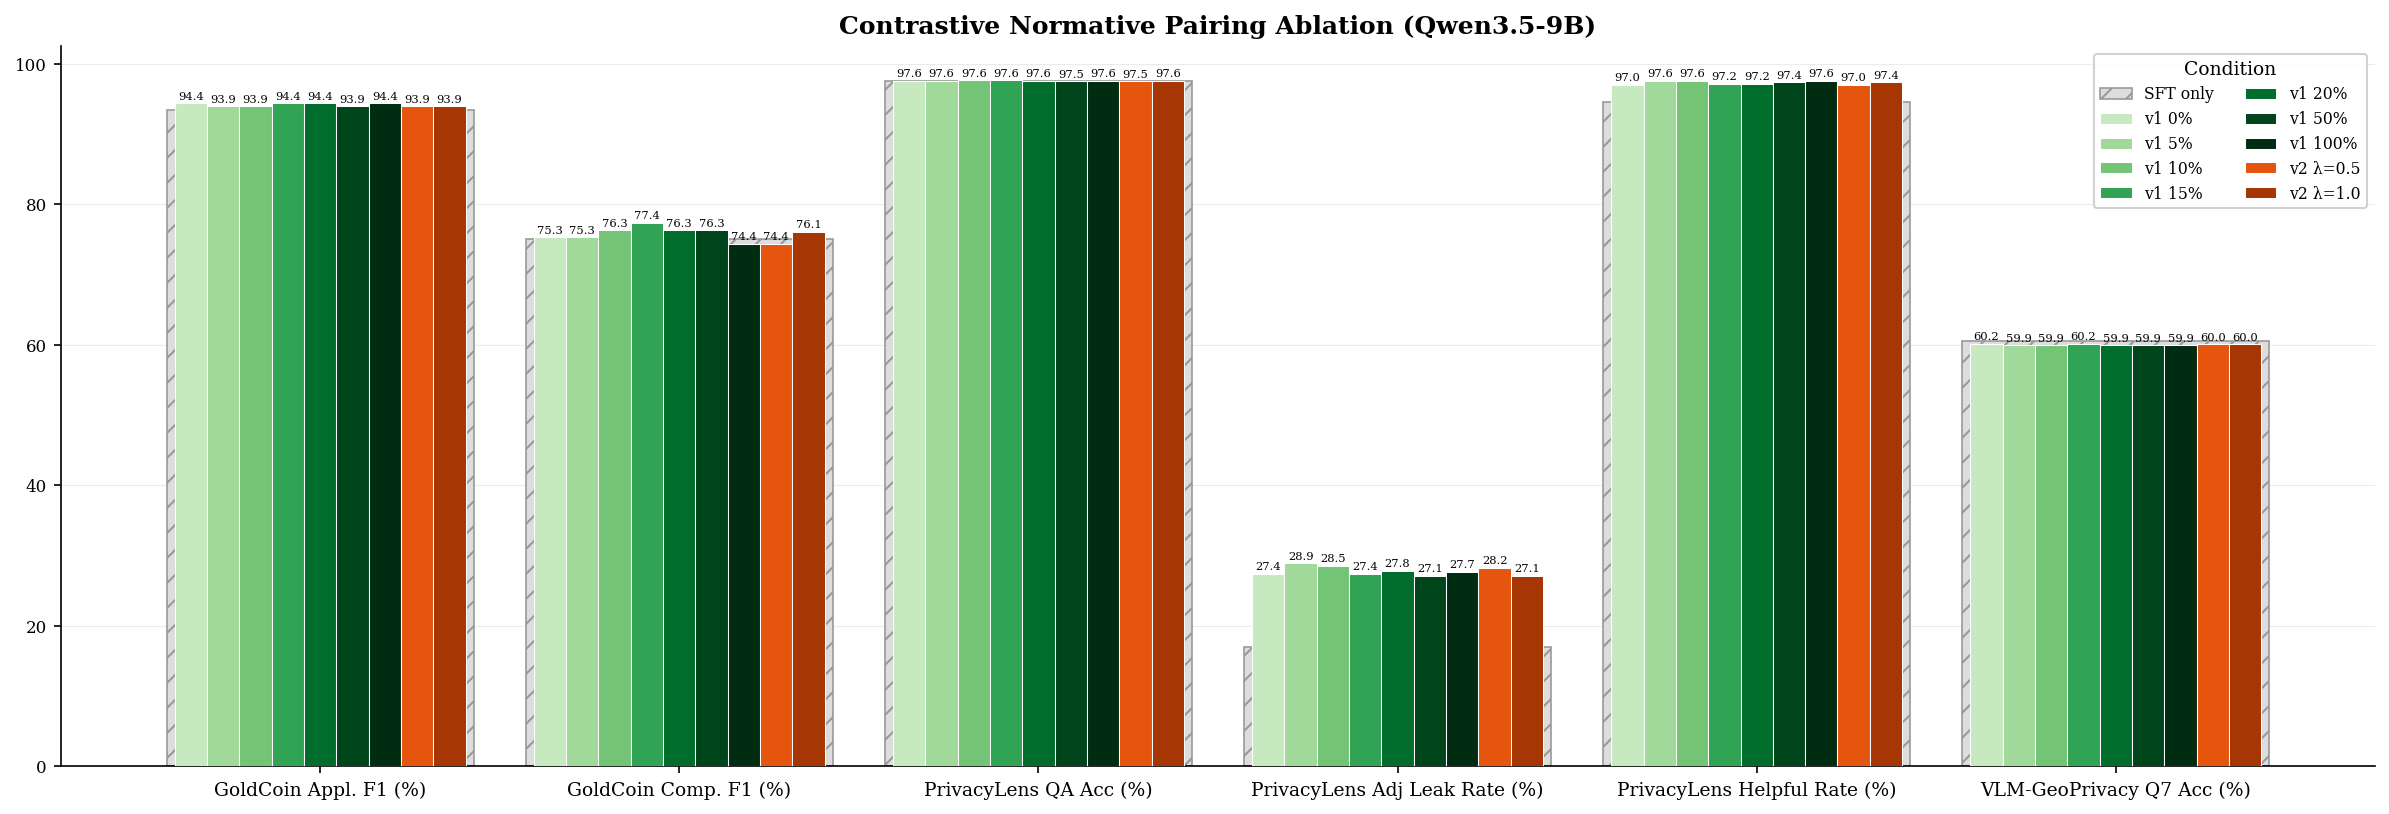

Saved contrastive_ablation.pdf


In [8]:
# ── Figure 1: Contrastive ablation bar chart (v1 + v2) ──
metric_spec = [
    ("App F1",    "GoldCoin Appl. F1 (%)",          True),
    ("Comp F1",   "GoldCoin Comp. F1 (%)",          True),
    ("QA Acc",    "PrivacyLens QA Acc (%)",          True),
    ("Adj Leak",  "PrivacyLens Adj Leak Rate (%)",   False),
    ("Helpful",   "PrivacyLens Helpful Rate (%)",    True),
    ("Q7 Acc",    "VLM-GeoPrivacy Q7 Acc (%)",       True),
]
# Filter to metrics that have data in at least one table
all_contrastive = pd.concat([df_contrastive_v1, df_contrastive_v2], ignore_index=True)
metric_spec = [(c, l, hb) for c, l, hb in metric_spec
               if c in all_contrastive.columns and all_contrastive[c].notna().any()]

# Build SFT baseline values for the dashed reference line
sft_vals_map = {}
if len(df_sft) > 0:
    sft_row = df_sft.iloc[0]
    for col, _, _ in metric_spec:
        sft_vals_map[col] = sft_row.get(col, np.nan)

# Combine v1 and v2 conditions into one sequence for bar positions
v1_entries = [(ratio, CONTRASTIVE_V1_LABELS.get(ratio, ""), CONTRASTIVE_V1_COLORS.get(ratio, "#999"))
              for ratio in contrastive_v1_order]
v2_entries = [(lam, CONTRASTIVE_V2_LABELS.get(lam, ""), CONTRASTIVE_V2_COLORS.get(lam, "#999"))
              for lam in contrastive_v2_order]
all_entries = v1_entries + v2_entries

n_metrics = len(metric_spec)
n_conditions = len(all_entries)
bar_w = 0.09
x = np.arange(n_metrics)

fig, ax = plt.subplots(figsize=(16, 5.5))

# SFT baseline bars (hatched, behind GRPO bars)
sft_baseline_vals = [sft_vals_map.get(col, np.nan) for col, _, _ in metric_spec]
sft_bar_width = bar_w * (n_conditions + 0.5)
ax.bar(x, sft_baseline_vals, sft_bar_width,
       color="#DDDDDD", edgecolor="#999999", linewidth=0.8,
       hatch="//", label="SFT only", zorder=2)

# Plot v1 bars
for j, ratio in enumerate(contrastive_v1_order):
    row = df_contrastive_v1[df_contrastive_v1["condition"] == ratio]
    if row.empty:
        continue
    row = row.iloc[0]
    vals = [row.get(col, np.nan) for col, _, _ in metric_spec]
    offset = (j - n_conditions / 2 + 0.5) * bar_w
    bars = ax.bar(x + offset, vals, bar_w,
                  color=CONTRASTIVE_V1_COLORS.get(ratio, "#999"),
                  label=f"v1 {int(ratio*100)}%",
                  edgecolor="white", linewidth=0.5, zorder=3)
    for bar in bars:
        h = bar.get_height()
        if pd.notna(h) and h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3,
                    f"{h:.1f}", ha="center", va="bottom", fontsize=5.5)

# Plot v2 bars (with distinct hatching to visually separate)
for j, lam in enumerate(contrastive_v2_order):
    row = df_contrastive_v2[df_contrastive_v2["condition"] == lam]
    if row.empty:
        continue
    row = row.iloc[0]
    vals = [row.get(col, np.nan) for col, _, _ in metric_spec]
    offset = (len(contrastive_v1_order) + j - n_conditions / 2 + 0.5) * bar_w
    bars = ax.bar(x + offset, vals, bar_w,
                  color=CONTRASTIVE_V2_COLORS.get(lam, "#E6550D"),
                  label=f"v2 λ={lam}",
                  edgecolor="white", linewidth=0.5, zorder=3)
    for bar in bars:
        h = bar.get_height()
        if pd.notna(h) and h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3,
                    f"{h:.1f}", ha="center", va="bottom", fontsize=5.5)

ax.set_xticks(x)
ax.set_xticklabels([label for _, label, _ in metric_spec], fontsize=9)
ax.set_title("Contrastive Normative Pairing Ablation (Qwen3.5-9B)", fontsize=12, fontweight="bold")
ax.legend(title="Condition", loc="upper right", framealpha=0.9, ncol=2)

plt.tight_layout()
fig.savefig("tables/contrastive_ablation.pdf")
fig.savefig(str(Path("/share/pierson/matt/papers/colm26_llm-praxis/tables/contrastive_ablation.pdf")))
plt.show()
print("Saved contrastive_ablation.pdf")


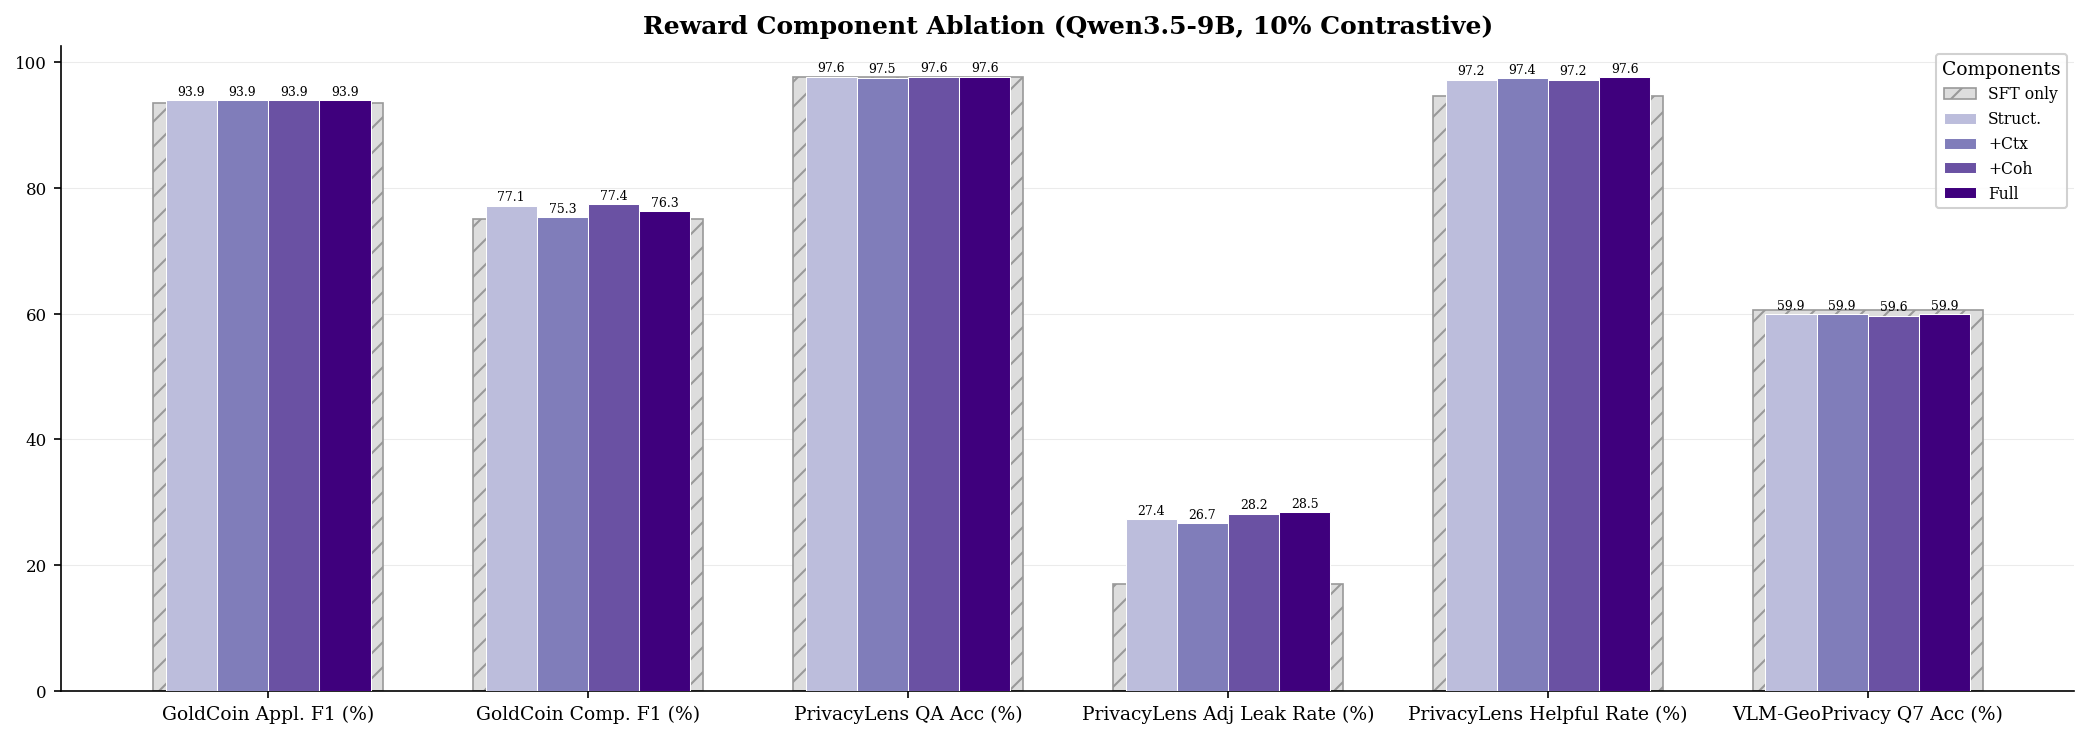

Saved reward_ablation.pdf


In [9]:
# ── Figure 2: Reward component ablation bar chart ──
metric_spec_reward = [(c, l, hb) for c, l, hb in [
    ("App F1",    "GoldCoin Appl. F1 (%)",          True),
    ("Comp F1",   "GoldCoin Comp. F1 (%)",          True),
    ("QA Acc",    "PrivacyLens QA Acc (%)",          True),
    ("Adj Leak",  "PrivacyLens Adj Leak Rate (%)",   False),
    ("Helpful",   "PrivacyLens Helpful Rate (%)",    True),
    ("Q7 Acc",    "VLM-GeoPrivacy Q7 Acc (%)",       True),
] if c in df_reward.columns and df_reward[c].notna().any()]

# SFT baseline values
sft_vals_map_r = {}
if len(df_sft) > 0:
    sft_row = df_sft.iloc[0]
    for col, _, _ in metric_spec_reward:
        sft_vals_map_r[col] = sft_row.get(col, np.nan)

n_metrics = len(metric_spec_reward)
n_conditions = len(reward_order)
bar_w = 0.16
x = np.arange(n_metrics)

fig, ax = plt.subplots(figsize=(14, 5))

# SFT baseline bars (hatched, behind)
sft_baseline_vals = [sft_vals_map_r.get(col, np.nan) for col, _, _ in metric_spec_reward]
sft_bar_width = bar_w * (n_conditions + 0.5)
ax.bar(x, sft_baseline_vals, sft_bar_width,
       color="#DDDDDD", edgecolor="#999999", linewidth=0.8,
       hatch="//", label="SFT only", zorder=2)

# Reward component bars
for j, rc in enumerate(reward_order):
    row = df_reward[df_reward["condition"] == rc]
    if row.empty:
        continue
    row = row.iloc[0]
    vals = [row.get(col, np.nan) for col, _, _ in metric_spec_reward]
    offset = (j - n_conditions / 2 + 0.5) * bar_w
    short_labels = {
        "structural": "Struct.",
        "+context": "+Ctx",
        "+coherence": "+Coh",
        "full": "Full",
    }
    bars = ax.bar(x + offset, vals, bar_w,
                  color=REWARD_COLORS[rc],
                  label=short_labels[rc],
                  edgecolor="white", linewidth=0.5, zorder=3)
    for bar in bars:
        h = bar.get_height()
        if pd.notna(h) and h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3,
                    f"{h:.1f}", ha="center", va="bottom", fontsize=6)

ax.set_xticks(x)
ax.set_xticklabels([label for _, label, _ in metric_spec_reward], fontsize=9)
ax.set_title("Reward Component Ablation (Qwen3.5-9B, 10% Contrastive)", fontsize=12, fontweight="bold")
ax.legend(title="Components", loc="upper right", framealpha=0.9)

plt.tight_layout()
fig.savefig("tables/reward_ablation.pdf")
fig.savefig(str(Path("/share/pierson/matt/papers/colm26_llm-praxis/tables/reward_ablation.pdf")))
plt.show()
print("Saved reward_ablation.pdf")

## 7. Reward trace analysis

Analyze training dynamics from reward traces to understand how components
evolve during training across ablation conditions.

In [10]:
import json

TRACE_BASE = Path("/share/pierson/matt/UAIR/multirun/2026-03-28_grpo_training")

trace_rows = []
for run_id, meta in ABLATION_RUNS.items():
    trace_path = TRACE_BASE / run_id / "grpo_only_online_external" / "outputs" / "grpo" / "checkpoint" / "reward_traces.jsonl"
    if not trace_path.exists():
        print(f"  {run_id}: no traces")
        continue
    with open(trace_path) as f:
        for line in f:
            entry = json.loads(line)
            entry["run_id"] = run_id
            entry.update(meta)
            trace_rows.append(entry)

df_traces = pd.DataFrame(trace_rows)
print(f"Loaded {len(df_traces)} trace entries from {df_traces['run_id'].nunique()} runs")

# Summary: mean composite by call number and ablation
if len(df_traces) > 0:
    summary = df_traces.groupby(["reward_config", "call"]).agg(
        composite_mean=("composite", "mean"),
        composite_std=("composite", "std"),
        n_no_flow=("is_no_flow", "sum"),
        n_total=("is_no_flow", "count"),
    ).reset_index()
    summary["no_flow_pct"] = summary["n_no_flow"] / summary["n_total"] * 100
    display(summary.round(3))

  11-28-41: no traces
  11-39-49: no traces
Loaded 44 trace entries from 10 runs


,reward_config,call,composite_mean,composite_std,n_no_flow,n_total,no_flow_pct
0,+coherence,0,0.486,0.505,1,4,25.000
1,+context,0,0.350,0.289,4,4,100.000
2,full,0,0.450,0.259,25,28,89.286
3,full,149,0.600,0.000,4,4,100.000
4,structural,0,0.558,0.343,3,4,75.000


NameError: name 'contrastive_order' is not defined

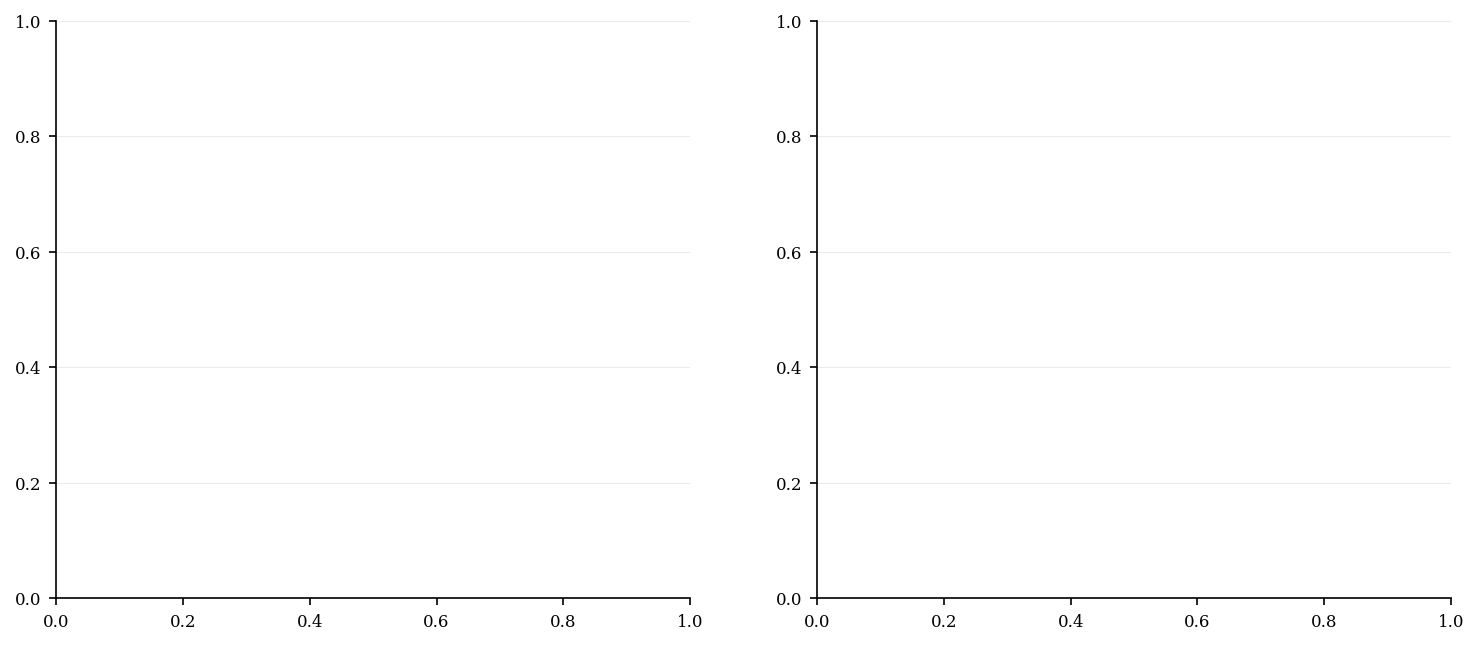

In [11]:
# ── Figure 3: Composite reward trajectory by ablation ──
if len(df_traces) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Panel 1: Reward trajectory for contrastive ablation
    for ratio in contrastive_order:
        sub = df_traces[(df_traces["ablation"] == "contrastive") & (df_traces["contrastive_ratio"] == ratio)]
        if sub.empty:
            continue
        means = sub.groupby("call")["composite"].mean()
        ax1.plot(means.index, means.values,
                 color=CONTRASTIVE_COLORS[ratio],
                 marker="o", markersize=4,
                 label=f"{int(ratio*100)}%")
    ax1.set_xlabel("Training call")
    ax1.set_ylabel("Mean composite reward")
    ax1.set_title("Contrastive Ablation", fontweight="bold")
    ax1.legend(title="Contrastive %")
    
    # Panel 2: Reward trajectory for reward component ablation
    for rc in reward_order:
        sub = df_traces[df_traces["reward_config"] == rc]
        if sub.empty:
            continue
        means = sub.groupby("call")["composite"].mean()
        short = {"structural": "Struct.", "+context": "+Ctx", "+coherence": "+Coh", "full": "Full"}
        ax2.plot(means.index, means.values,
                 color=REWARD_COLORS[rc],
                 marker="o", markersize=4,
                 label=short[rc])
    ax2.set_xlabel("Training call")
    ax2.set_ylabel("Mean composite reward")
    ax2.set_title("Reward Component Ablation", fontweight="bold")
    ax2.legend(title="Components")
    
    fig.suptitle("Training Reward Trajectories (Qwen3.5-9B)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    fig.savefig("tables/reward_trajectories.pdf")
    fig.savefig(str(Path("/share/pierson/matt/papers/colm26_llm-praxis/tables/reward_trajectories.pdf")))
    plt.show()
    print("Saved reward_trajectories.pdf")